In [2]:
from pathlib import Path

print(Path.cwd())

C:\Users\sujal\PycharmProjects\bluestock_mf_capstone\notebooks


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Current Directory:", Path.cwd())

BASE_DIR = Path.cwd().parent.parent

# If notebook is directly inside notebooks/
if not (BASE_DIR / "data").exists():
    BASE_DIR = Path.cwd().parent

print("Project Root:", BASE_DIR)

nav_history = pd.read_csv(
    BASE_DIR / "data" / "processed" / "clean_nav_history_filled.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data" / "raw" / "01_fund_master.csv"
)

print(nav_history.shape)
print(fund_master.shape)

Current Directory: C:\Users\sujal\PycharmProjects\bluestock_mf_capstone\notebooks
Project Root: C:\Users\sujal\PycharmProjects\bluestock_mf_capstone
(64320, 3)
(40, 15)


In [4]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [5]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


In [6]:
nav_history["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [7]:
nav_history["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [8]:
cagr_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    n_days = (
        group["date"].max()
        - group["date"].min()
    ).days

    years = n_days / 365.25

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    cagr_results.append(
        [amfi_code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [9]:
volatility_df = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(252)
)

volatility_df = volatility_df.reset_index()

volatility_df.columns = [
    "amfi_code",
    "annual_volatility"
]

volatility_df.head()

,amfi_code,annual_volatility
0,100016,0.123004
1,100025,0.033040
2,100033,0.160291
3,101206,0.123321
4,101207,0.218130


In [10]:
risk_free_rate = 0.06

sharpe_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    mean_return = (
        group["daily_return"]
        .mean()
        * 252
    )

    volatility = (
        group["daily_return"]
        .std()
        * np.sqrt(252)
    )

    sharpe = (
        (mean_return - risk_free_rate)
        / volatility
    )

    sharpe_results.append(
        [amfi_code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.280370
1,100025,-0.888610
2,100033,0.839461
3,101206,0.757954
4,101207,0.075540


In [11]:
metrics = (
    cagr_df
    .merge(
        volatility_df,
        on="amfi_code"
    )
    .merge(
        sharpe_df,
        on="amfi_code"
    )
)

metrics.head()

,amfi_code,cagr,annual_volatility,sharpe_ratio
0,100016,0.026371,0.123004,-0.280370
1,100025,0.044582,0.033040,-0.888610
2,100033,0.301232,0.160291,0.839461
3,101206,0.235384,0.123321,0.757954
4,101207,0.079388,0.218130,0.075540


In [12]:
top_sharpe = (
    metrics
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe

,amfi_code,cagr,annual_volatility,sharpe_ratio
34,148567,0.309741,0.120250,1.109804
30,120843,0.309075,0.134543,1.002723
36,148569,0.319495,0.149645,0.952459
25,120505,0.328274,0.163311,0.913872
19,119551,0.258047,0.116365,0.903945
38,149323,0.295811,0.150229,0.866168
2,100033,0.301232,0.160291,0.839461
9,118632,0.240495,0.119781,0.800594
16,119094,0.282144,0.164246,0.760989
3,101206,0.235384,0.123321,0.757954


In [13]:
top_sharpe

,amfi_code,cagr,annual_volatility,sharpe_ratio
34,148567,0.309741,0.120250,1.109804
30,120843,0.309075,0.134543,1.002723
36,148569,0.319495,0.149645,0.952459
25,120505,0.328274,0.163311,0.913872
19,119551,0.258047,0.116365,0.903945
38,149323,0.295811,0.150229,0.866168
2,100033,0.301232,0.160291,0.839461
9,118632,0.240495,0.119781,0.800594
16,119094,0.282144,0.164246,0.760989
3,101206,0.235384,0.123321,0.757954


In [14]:
risk_free_rate = 0.06

sortino_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    annual_return = (
        group["daily_return"].mean() * 252
    )

    downside_returns = group[
        group["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        (annual_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append(
        [amfi_code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.412951
1,100025,-1.248585
2,100033,1.188375
3,101206,1.124036
4,101207,0.108632


In [15]:
drawdown_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date")

    cumulative_max = group["nav"].cummax()

    drawdown = (
        group["nav"]
        - cumulative_max
    ) / cumulative_max

    max_drawdown = drawdown.min()

    drawdown_results.append(
        [amfi_code, max_drawdown]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()


,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [16]:
var_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    var_95 = np.percentile(
        group["daily_return"].dropna(),
        5
    )

    var_results.append(
        [amfi_code, var_95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=["amfi_code", "var_95"]
)

var_df.head()

,amfi_code,var_95
0,100016,-0.012884
1,100025,-0.003338
2,100033,-0.016902
3,101206,-0.012173
4,101207,-0.023915


In [17]:
metrics = (
    metrics
    .merge(
        sortino_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
    .merge(
        var_df,
        on="amfi_code"
    )
)

metrics.head()

,amfi_code,cagr,annual_volatility,sharpe_ratio,sortino_ratio,max_drawdown,var_95
0,100016,0.026371,0.123004,-0.280370,-0.412951,-0.247344,-0.012884
1,100025,0.044582,0.033040,-0.888610,-1.248585,-0.043083,-0.003338
2,100033,0.301232,0.160291,0.839461,1.188375,-0.162172,-0.016902
3,101206,0.235384,0.123321,0.757954,1.124036,-0.112916,-0.012173
4,101207,0.079388,0.218130,0.075540,0.108632,-0.354469,-0.023915


In [18]:
metrics.to_csv(
    BASE_DIR / "data" / "processed" / "performance_metrics.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [19]:
final_rankings = (
    metrics
    .merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code"
    )
)

final_rankings = final_rankings.sort_values(
    "sharpe_ratio",
    ascending=False
)

final_rankings[
    [
        "scheme_name",
        "cagr",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown"
    ]
].head(10)

,scheme_name,cagr,sharpe_ratio,sortino_ratio,max_drawdown
34,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,1.109804,1.548765,-0.112657
30,Kotak Flexicap Fund - Regular - Growth,0.309075,1.002723,1.536447,-0.129740
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,0.952459,1.401997,-0.163967
25,ICICI Pru Midcap Fund - Regular - Growth,0.328274,0.913872,1.330414,-0.181885
19,SBI Bluechip Fund - Regular Plan - Growth,0.258047,0.903945,1.355936,-0.150124
38,DSP Midcap Fund - Regular - Growth,0.295811,0.866168,1.214459,-0.172481
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,0.839461,1.188375,-0.162172
9,Nippon India Large Cap Fund - Regular - Growth,0.240495,0.800594,1.159327,-0.174141
16,Axis Midcap Fund - Regular - Growth,0.282144,0.760989,1.099258,-0.209609
3,ABSL Frontline Equity Fund - Regular - Growth,0.235384,0.757954,1.124036,-0.112916


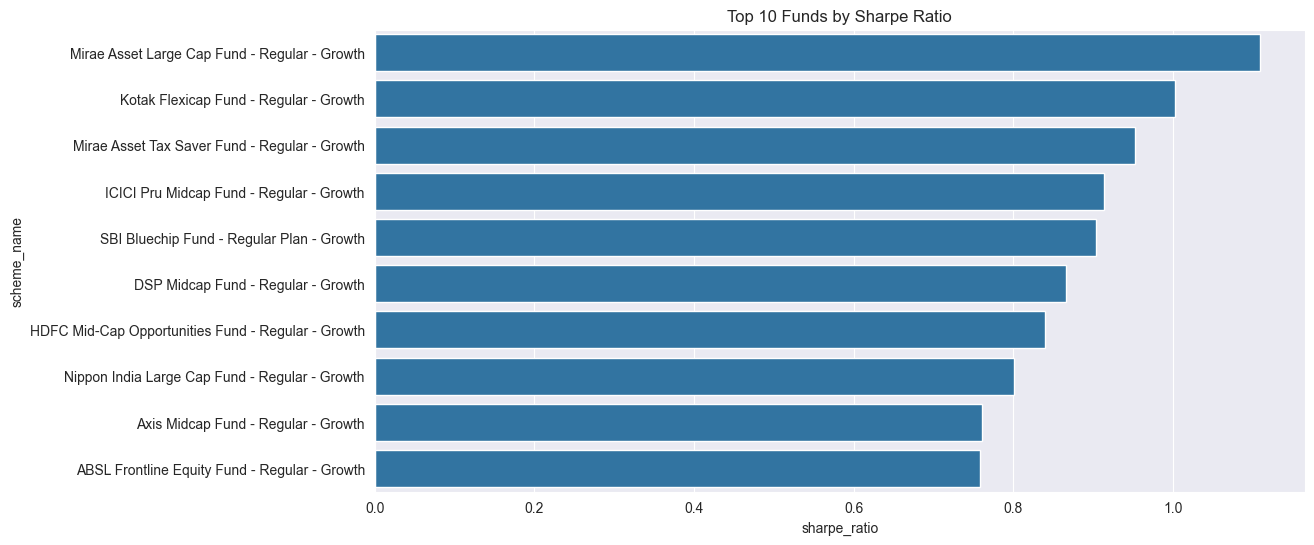

In [20]:
top10 = final_rankings.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.show()

## Insight: Risk-Adjusted Performance

- Sharpe Ratio ranks funds based on return generated per unit of risk.
- The top-ranked funds demonstrate superior risk-adjusted performance.
- These funds are strong candidates for portfolio construction and recommendation engines.

In [21]:
metrics.head()

,amfi_code,cagr,annual_volatility,sharpe_ratio,sortino_ratio,max_drawdown,var_95
0,100016,0.026371,0.123004,-0.280370,-0.412951,-0.247344,-0.012884
1,100025,0.044582,0.033040,-0.888610,-1.248585,-0.043083,-0.003338
2,100033,0.301232,0.160291,0.839461,1.188375,-0.162172,-0.016902
3,101206,0.235384,0.123321,0.757954,1.124036,-0.112916,-0.012173
4,101207,0.079388,0.218130,0.075540,0.108632,-0.354469,-0.023915


In [22]:
final_rankings.head(10)

,amfi_code,cagr,annual_volatility,sharpe_ratio,sortino_ratio,max_drawdown,var_95,scheme_name
34,148567,0.309741,0.120250,1.109804,1.548765,-0.112657,-0.012607,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.309075,0.134543,1.002723,1.536447,-0.129740,-0.013327,Kotak Flexicap Fund - Regular - Growth
36,148569,0.319495,0.149645,0.952459,1.401997,-0.163967,-0.015259,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.328274,0.163311,0.913872,1.330414,-0.181885,-0.016224,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.258047,0.116365,0.903945,1.355936,-0.150124,-0.011827,SBI Bluechip Fund - Regular Plan - Growth
38,149323,0.295811,0.150229,0.866168,1.214459,-0.172481,-0.015866,DSP Midcap Fund - Regular - Growth
2,100033,0.301232,0.160291,0.839461,1.188375,-0.162172,-0.016902,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.240495,0.119781,0.800594,1.159327,-0.174141,-0.012333,Nippon India Large Cap Fund - Regular - Growth
16,119094,0.282144,0.164246,0.760989,1.099258,-0.209609,-0.016997,Axis Midcap Fund - Regular - Growth
3,101206,0.235384,0.123321,0.757954,1.124036,-0.112916,-0.012173,ABSL Frontline Equity Fund - Regular - Growth


In [23]:
final_rankings = (
    metrics
    .merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code",
        how="left"
    )
)

final_rankings = final_rankings.sort_values(
    "sharpe_ratio",
    ascending=False
)

final_rankings[
    [
        "scheme_name",
        "cagr",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown"
    ]
].head(10)

,scheme_name,cagr,sharpe_ratio,sortino_ratio,max_drawdown
34,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,1.109804,1.548765,-0.112657
30,Kotak Flexicap Fund - Regular - Growth,0.309075,1.002723,1.536447,-0.129740
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,0.952459,1.401997,-0.163967
25,ICICI Pru Midcap Fund - Regular - Growth,0.328274,0.913872,1.330414,-0.181885
19,SBI Bluechip Fund - Regular Plan - Growth,0.258047,0.903945,1.355936,-0.150124
38,DSP Midcap Fund - Regular - Growth,0.295811,0.866168,1.214459,-0.172481
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,0.839461,1.188375,-0.162172
9,Nippon India Large Cap Fund - Regular - Growth,0.240495,0.800594,1.159327,-0.174141
16,Axis Midcap Fund - Regular - Growth,0.282144,0.760989,1.099258,-0.209609
3,ABSL Frontline Equity Fund - Regular - Growth,0.235384,0.757954,1.124036,-0.112916


In [24]:
final_rankings.to_csv(
    BASE_DIR / "data" / "processed" / "fund_rankings.csv",
    index=False
)

print("Fund rankings saved")

Fund rankings saved


# Performance Analytics Summary

## Objectives

The objective of this analysis was to evaluate mutual fund performance using risk-adjusted metrics and portfolio analytics techniques.

## Metrics Calculated

* CAGR (Compound Annual Growth Rate)
* Annualized Volatility
* Sharpe Ratio
* Sortino Ratio
* Maximum Drawdown
* Value at Risk (95%)

## Key Findings

### Return Analysis

* CAGR values ranged from approximately 2.6% to 32.8%.
* Several mid-cap and flexi-cap funds demonstrated superior long-term growth.

### Risk Analysis

* Annualized volatility varied significantly across schemes.
* Funds with higher returns often exhibited higher risk levels.

### Risk-Adjusted Performance

* Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio.
* Kotak Flexicap Fund and Mirae Asset Tax Saver Fund also ranked highly.
* Sortino Ratios confirmed strong downside-risk-adjusted performance for the top-ranked schemes.

### Drawdown Analysis

* Maximum drawdowns ranged between approximately 4% and 35%.
* Some funds delivered strong returns while maintaining relatively controlled drawdowns.

### Value at Risk

* VaR estimates provide a measure of potential downside risk under normal market conditions.
* Higher-risk funds exhibited larger negative VaR values.

## Conclusion

Risk-adjusted metrics provide a more comprehensive evaluation framework than return metrics alone. The resulting rankings can support investor decision-making, recommendation systems, portfolio construction, and dashboard reporting.
